# Search a remote database with MCP

## MCP tool design

These practices do not depend on the agent framework.

- Give each tool one narrow, read-only operation.
- Use explicit parameter types, validation, and descriptions; these form the tool schema the agent reads.
- Use the docstring to state when to call the tool, its inputs, returns, and errors.
- Split search from record retrieval so the agent receives only the evidence it needs.
- Return exact source text with record IDs, URLs, retrieval times, and HTTP status. Mark truncated fields and additional pages.
- Report validation, access, and API errors with enough detail to correct the call.

**Pros**

- The database stays remote; only limited search results and selected records enter agent context.
- Results include record IDs, source URLs, retrieval times, HTTP status, truncation, and pagination.
- The same MCP server works with LangGraph, Archi, or another MCP client.

**Cons**

- The detector database still needs a read-only API.
- Search and record limits must be tested against real detector questions.
- Archi adds chatbot, data-manager, and PostgreSQL containers; document ingestion is disabled here.

This notebook uses the public GitHub Issues API for CMS CMSSW. For the detector database, replace the endpoints and map its fields to the same result schema. Then change the question and inspect the exact tool results.

In [1]:
REQUEST = """
Use the GitHub Issues API at https://api.github.com/search/issues to search
the cms-sw/cmssw repository.

For the crash in run 382461 involving cudaErrorInvalidConfiguration, what
caused it, which fixes were merged, and in which release was the result
confirmed? Cite the records you used.
"""

In [2]:
# Use a Python 3.12 kernel. Run this cell once.
%pip install -q \
    "langchain==1.4.0" "langgraph==1.2.11" "langchain-openai==1.6.1" \
    "langchain-mcp-adapters==0.3.2" "mcp==1.30.0" "httpx==0.28.1" "pydantic==2.13.5"

## Two MCP tools

```text
API URL + search terms ──search_records──> at most 5 results
selected record ID ──get_record──> issue and at most 10 issue comments
```

In [ ]:
%%writefile /tmp/database_api_mcp_demo.py
# Write the server once; each following cell adds one tool.

from datetime import datetime, timezone
from typing import Annotated, Any, Literal

import httpx
from mcp.server.fastmcp import FastMCP
from pydantic import Field

mcp = FastMCP("Database API tools", host="0.0.0.0", port=8000)
REPOSITORY = "cms-sw/cmssw"  # Repository searched by these tools

SEARCH_LIMIT = 5  # Maximum search results returned to the agent

# Human-written GitHub issue comments returned with one record.
ISSUE_COMMENT_LIMIT = 10

SEARCH_API = "https://api.github.com/search/issues"  # Search without loading full records
RECORD_API = "https://api.github.com/repos/cms-sw/cmssw/issues"  # Retrieve one issue and its issue comments


In [ ]:
%%writefile -a /tmp/database_api_mcp_demo.py
# Append this tool to the server file created above.

@mcp.tool()
def search_records(
    # Literal and Field constraints are exposed in the MCP input schema.
    api_url: Literal[SEARCH_API],
    query: Annotated[
        str,
        Field(
            description="Search terms; the tool adds the repository scope.",
            min_length=1,
            max_length=300,
        ),
    ],
) -> dict[str, Any]:
    """Search CMS CMSSW issues without loading full issues.

    Use this tool to find candidate issues while keeping the result small.

    Args:
        api_url: Supported GitHub Issues search endpoint shown in the user request.
        query: API search expression for the user's question. The tool adds
            the supported repository scope.
    Returns:
        Up to five issue numbers, titles, URLs, and exact 600-character
        excerpts, plus source and retrieval metadata.
    Raises:
        ValueError: The API status and response body when the request fails.
    """

    response = httpx.get(
        api_url, params={"q": f"repo:{REPOSITORY} {query}", "per_page": SEARCH_LIMIT}, timeout=10
    )
    # Keep API errors short but specific enough to correct the request.
    if response.is_error:
        raise ValueError(f"API returned HTTP {response.status_code}: {response.text[:1000]}")
    # Return only enough information to select a record.
    records = [
        {
            "record_id": item["number"],
            "title": item["title"],
            "source_url": item["html_url"],
            "excerpt": item.get("body", "")[:600],
        }
        for item in response.json()["items"][:SEARCH_LIMIT]
    ]
    # Include stable record IDs and source metadata with the limited result set.
    return {
        "status": "ok",
        "records": records,
        "next_action": "Use get_record with a selected record_id when supporting detail is needed.",
        "source_url": str(response.url),
        "retrieved_at": datetime.now(timezone.utc).isoformat(),
        "http_status": response.status_code,
    }


In [5]:
%%writefile -a /tmp/database_api_mcp_demo.py

@mcp.tool()
def get_record(
    record_id: Annotated[int, Field(description="Positive record ID returned by search_records.", gt=0)],
) -> dict[str, Any]:
    """Retrieve one CMS CMSSW issue and its human-written issue comments.

    Use when the short fields returned by search_records do not contain enough
    evidence to answer. Returned text is copied from the API without LLM
    summarization.

    Args:
        record_id: A CMS issue number returned by search_records.

    Returns:
        Issue fields and up to ten issue comments. Truncated fields and
        additional issue-comment pages are marked. Each API response includes its URL,
        retrieval time, and HTTP status.
    Raises:
        ValueError: The API status and response body when either request fails.
    """
    issue_response = httpx.get(f"{RECORD_API}/{record_id}", timeout=10)
    issue_comments_response = httpx.get(
        f"{RECORD_API}/{record_id}/comments", params={"per_page": ISSUE_COMMENT_LIMIT}, timeout=10
    )
    for response in (issue_response, issue_comments_response):
        if response.is_error:
            raise ValueError(f"API returned HTTP {response.status_code}: {response.text[:1000]}")
    issue = issue_response.json()
    issue_comments = issue_comments_response.json()
    body = issue.get("body", "")
    # Mark truncated fields and additional issue-comment pages.
    return {
        "status": "ok",
        "record": {
            "record_id": issue["number"],
            "title": issue["title"],
            "body_start": body if len(body) <= 2_000 else body[:1_000],
            "body_end": "" if len(body) <= 2_000 else body[-1_000:],
            "body_truncated": len(body) > 2_000,
            "issue_comments": [
                {
                    "issue_comment_id": item["id"],
                    "text": item.get("body", "")[:1_000],
                    "text_truncated": len(item.get("body", "")) > 1_000,
                    "source_url": item["html_url"],
                }
                for item in issue_comments
            ],
            "more_issue_comments_available": "next" in issue_comments_response.links,
            "source_url": issue["html_url"],
        },
        "provenance": [
            {
                "source_url": str(response.url),
                "retrieved_at": datetime.now(timezone.utc).isoformat(),
                "http_status": response.status_code,
            }
            for response in (issue_response, issue_comments_response)
        ],
    }

if __name__ == "__main__":
    mcp.run(transport="streamable-http")


In [ ]:
# Start the MCP server for either client. Leave this kernel running.
import subprocess
import sys
import time

mcp_process = subprocess.Popen([sys.executable, "/tmp/database_api_mcp_demo.py"])
time.sleep(1)

## Run with LangGraph

The next cells run a small agent, show the exact MCP results, and then show the agent's answer.

In [ ]:
import os
from langchain.agents import create_agent
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_openai import ChatOpenAI

client = MultiServerMCPClient(
    {
        "database": {
            "transport": "streamable_http",
            "url": "http://127.0.0.1:8000/mcp",
        }
    }
)
# Set these variables to use another OpenAI-compatible model endpoint.
model = ChatOpenAI(
    base_url=os.getenv("OPENAI_BASE_URL", "http://127.0.0.1:8080/v1"),
    api_key=os.getenv("OPENAI_API_KEY", "local"),
    model=os.getenv("OPENAI_MODEL", "gemma-4-26b-a4b-it-4bit"),
    temperature=0,
    max_completion_tokens=900,
)
tools = await client.get_tools()
agent = create_agent(model, tools)
result = await agent.ainvoke({"messages": [{"role": "user", "content": REQUEST}]})

In [7]:
# Show the exact MCP results, then the agent's answer.
display(*[message.artifact["structured_content"] for message in result["messages"] if message.type == "tool"])
result["messages"][-1].content

{'status': 'ok',
 'records': [{'record_id': 45312,
   'title': 'HLT crashes in Run 382461',
   'source_url': 'https://github.com/cms-sw/cmssw/issues/45312',
   'excerpt': "Crashes observed in collisions Run [382461](https://cmsoms.cern.ch/cms/triggers/report?cms_run=382461). Error message:\r\n\r\n```\r\n----- Begin Fatal Exception 26-Jun-2024 14:33:41 CEST-----------------------\r\nAn exception of category 'StdException' occurred while\r\n   [0] Processing  Event run: 382461 lumi: 2 event: 4698821 stream: 0\r\n   [1] Running path 'DQM_EcalReconstruction_v10'\r\n   [2] Calling method for module EcalUncalibRecHitProducerPortable@alpaka/'hltEcalUncalibRecHitSoA'\r\nException Message:\r\nA std::exception was thrown.\r\n/data/cmsbld/jenkins/workspace/auto-builds/CMSSW_14_0_9_MULTIARCHS-"}],
 'next_action': 'Use get_record with a selected record_id when supporting detail is needed.',
 'source_url': 'https://api.github.com/search/issues?q=repo%3Acms-sw%2Fcmssw+run+382461+cudaErrorInvalidConfi

{'status': 'ok',
 'record': {'record_id': 45312,
  'title': 'HLT crashes in Run 382461',
  'body_start': "Crashes observed in collisions Run [382461](https://cmsoms.cern.ch/cms/triggers/report?cms_run=382461). Error message:\r\n\r\n```\r\n----- Begin Fatal Exception 26-Jun-2024 14:33:41 CEST-----------------------\r\nAn exception of category 'StdException' occurred while\r\n   [0] Processing  Event run: 382461 lumi: 2 event: 4698821 stream: 0\r\n   [1] Running path 'DQM_EcalReconstruction_v10'\r\n   [2] Calling method for module EcalUncalibRecHitProducerPortable@alpaka/'hltEcalUncalibRecHitSoA'\r\nException Message:\r\nA std::exception was thrown.\r\n/data/cmsbld/jenkins/workspace/auto-builds/CMSSW_14_0_9_MULTIARCHS-el8_amd64_gcc12/build/CMSSW_14_0_9_MULTIARCHS-b\\\r\nuild/el8_amd64_gcc12/external/alpaka/1.1.0-c6af69ddd6f2ee5be4f2b069590bae19/include/alpaka/kernel/TaskKernelGpuUni\\\r\nformCudaHipRt.hpp(259) 'TApi::setDevice(queue.m_spQueueImpl->m_dev.getNativeHandle())' A previous API

'The crash in run 382461 involving `cudaErrorInvalidConfiguration` was caused by a specific kernel that was "barrel-only" (it only operated on the ECAL barrel), which bypassed existing protections designed for empty ECAL events that relied on total size.\n\n**Summary of findings:**\n*   **Cause:** A kernel in the `EcalUncalibRecHitProducerPortable` module was sensitive to the absence of the ECAL barrel. While protections existed for empty ECAL events, they did not account for this specific barrel-only kernel.\n*   **Fixes Merged:** Three pull requests were merged to address the issue across different branches:\n    *   [PR #45311](https://github.com/cms-sw/cmssw/pull/45311) (master branch)\n    *   [PR #45313](https://github.com/cms-sw/cmssw/pull/45313) (14.0.X branch)\n    *   [PR #45314](https://github.com/cms-sw/cmssw/pull/45314) (14.0.9_patchX branch)\n*   **Release Confirmation:** The fix was confirmed to be effective on the affected data and will be available in the **`CMSSW_14_0

## Optional: ask the same question through Archi

Requirements:

1. Start an OpenAI-compatible model at `http://127.0.0.1:8080/v1`.
2. Start Podman. On macOS or Windows, use `podman machine init --now` once and `podman machine start` later. See [Podman installation](https://podman.io/docs/installation) for installation or VM errors.
3. Run the MCP server cell above; leave the notebook kernel running.

The cells below start Archi's chatbot, data-manager, and PostgreSQL containers. Document ingestion stays disabled.

### 1. Install Archi

Archi reads deployment files from its repository, so install the pinned revision as an editable checkout.

In [ ]:
%pip install -q --disable-pip-version-check -e "git+https://github.com/archi-physics/archi.git@6e514043466614c08803b87b2efcae5d0452bd99#egg=archi"

from pathlib import Path
import os
import secrets
import sys

# Add commands installed in this kernel to PATH for the shell cells below.
os.environ["PATH"] = f"{Path(sys.executable).parent}:{os.environ['PATH']}"
Path("/tmp/archi-mcp-demo/agents").mkdir(parents=True, exist_ok=True)


### 2. Configure Archi

The agent file enables MCP tools. The configuration connects Archi's containers to the model and MCP server running on the host.

In [ ]:
%%writefile /tmp/archi-mcp-demo/agents/mcp.md
---
name: mcp
tools:
  - mcp
---

Use the available MCP tools when they provide evidence for the user's question.


In [ ]:
%%writefile /tmp/archi-mcp-demo/config.yaml
name: mcp_demo
services:
  chat_app:
    agent_class: CMSCompOpsAgent
    agents_dir: /tmp/archi-mcp-demo/agents
    # Change these values for another OpenAI-compatible model endpoint.
    default_provider: local
    default_model: gemma-4-26b-a4b-it-4bit
    providers:
      local:
        base_url: http://host.containers.internal:8080/v1  # model running on the host
        mode: openai_compat
        models: [gemma-4-26b-a4b-it-4bit]
mcp_servers:
  database:
    transport: streamable_http
    url: http://host.containers.internal:8000/mcp  # MCP server running on the host
data_manager:
  sources:
    links:
      enabled: false  # do not start document ingestion


In [ ]:
# Archi's PostgreSQL container requires this secret.
env_file = Path("/tmp/archi-mcp-demo/archi.env")
env_file.write_text("PG_PASSWORD=" + secrets.token_urlsafe(24) + "\n")
env_file.chmod(0o600)


### 3. Start Archi

Start Archi. Its required data-manager and PostgreSQL services are added automatically. The first build may take several minutes.

In [ ]:
!archi create --name mcp-demo \
    --config /tmp/archi-mcp-demo/config.yaml \
    --env-file /tmp/archi-mcp-demo/archi.env \
    --services chatbot --podman

import webbrowser
webbrowser.open("http://127.0.0.1:7861")


### 4. Ask the same question

A browser tab opens at [Archi](http://127.0.0.1:7861). Paste the question shown at the top and view the MCP calls in the activity panel.

### Recorded run

The activity panel shows `search_records` followed by `get_record`. The answer cites the retrieved issue and its human-written issue comments.

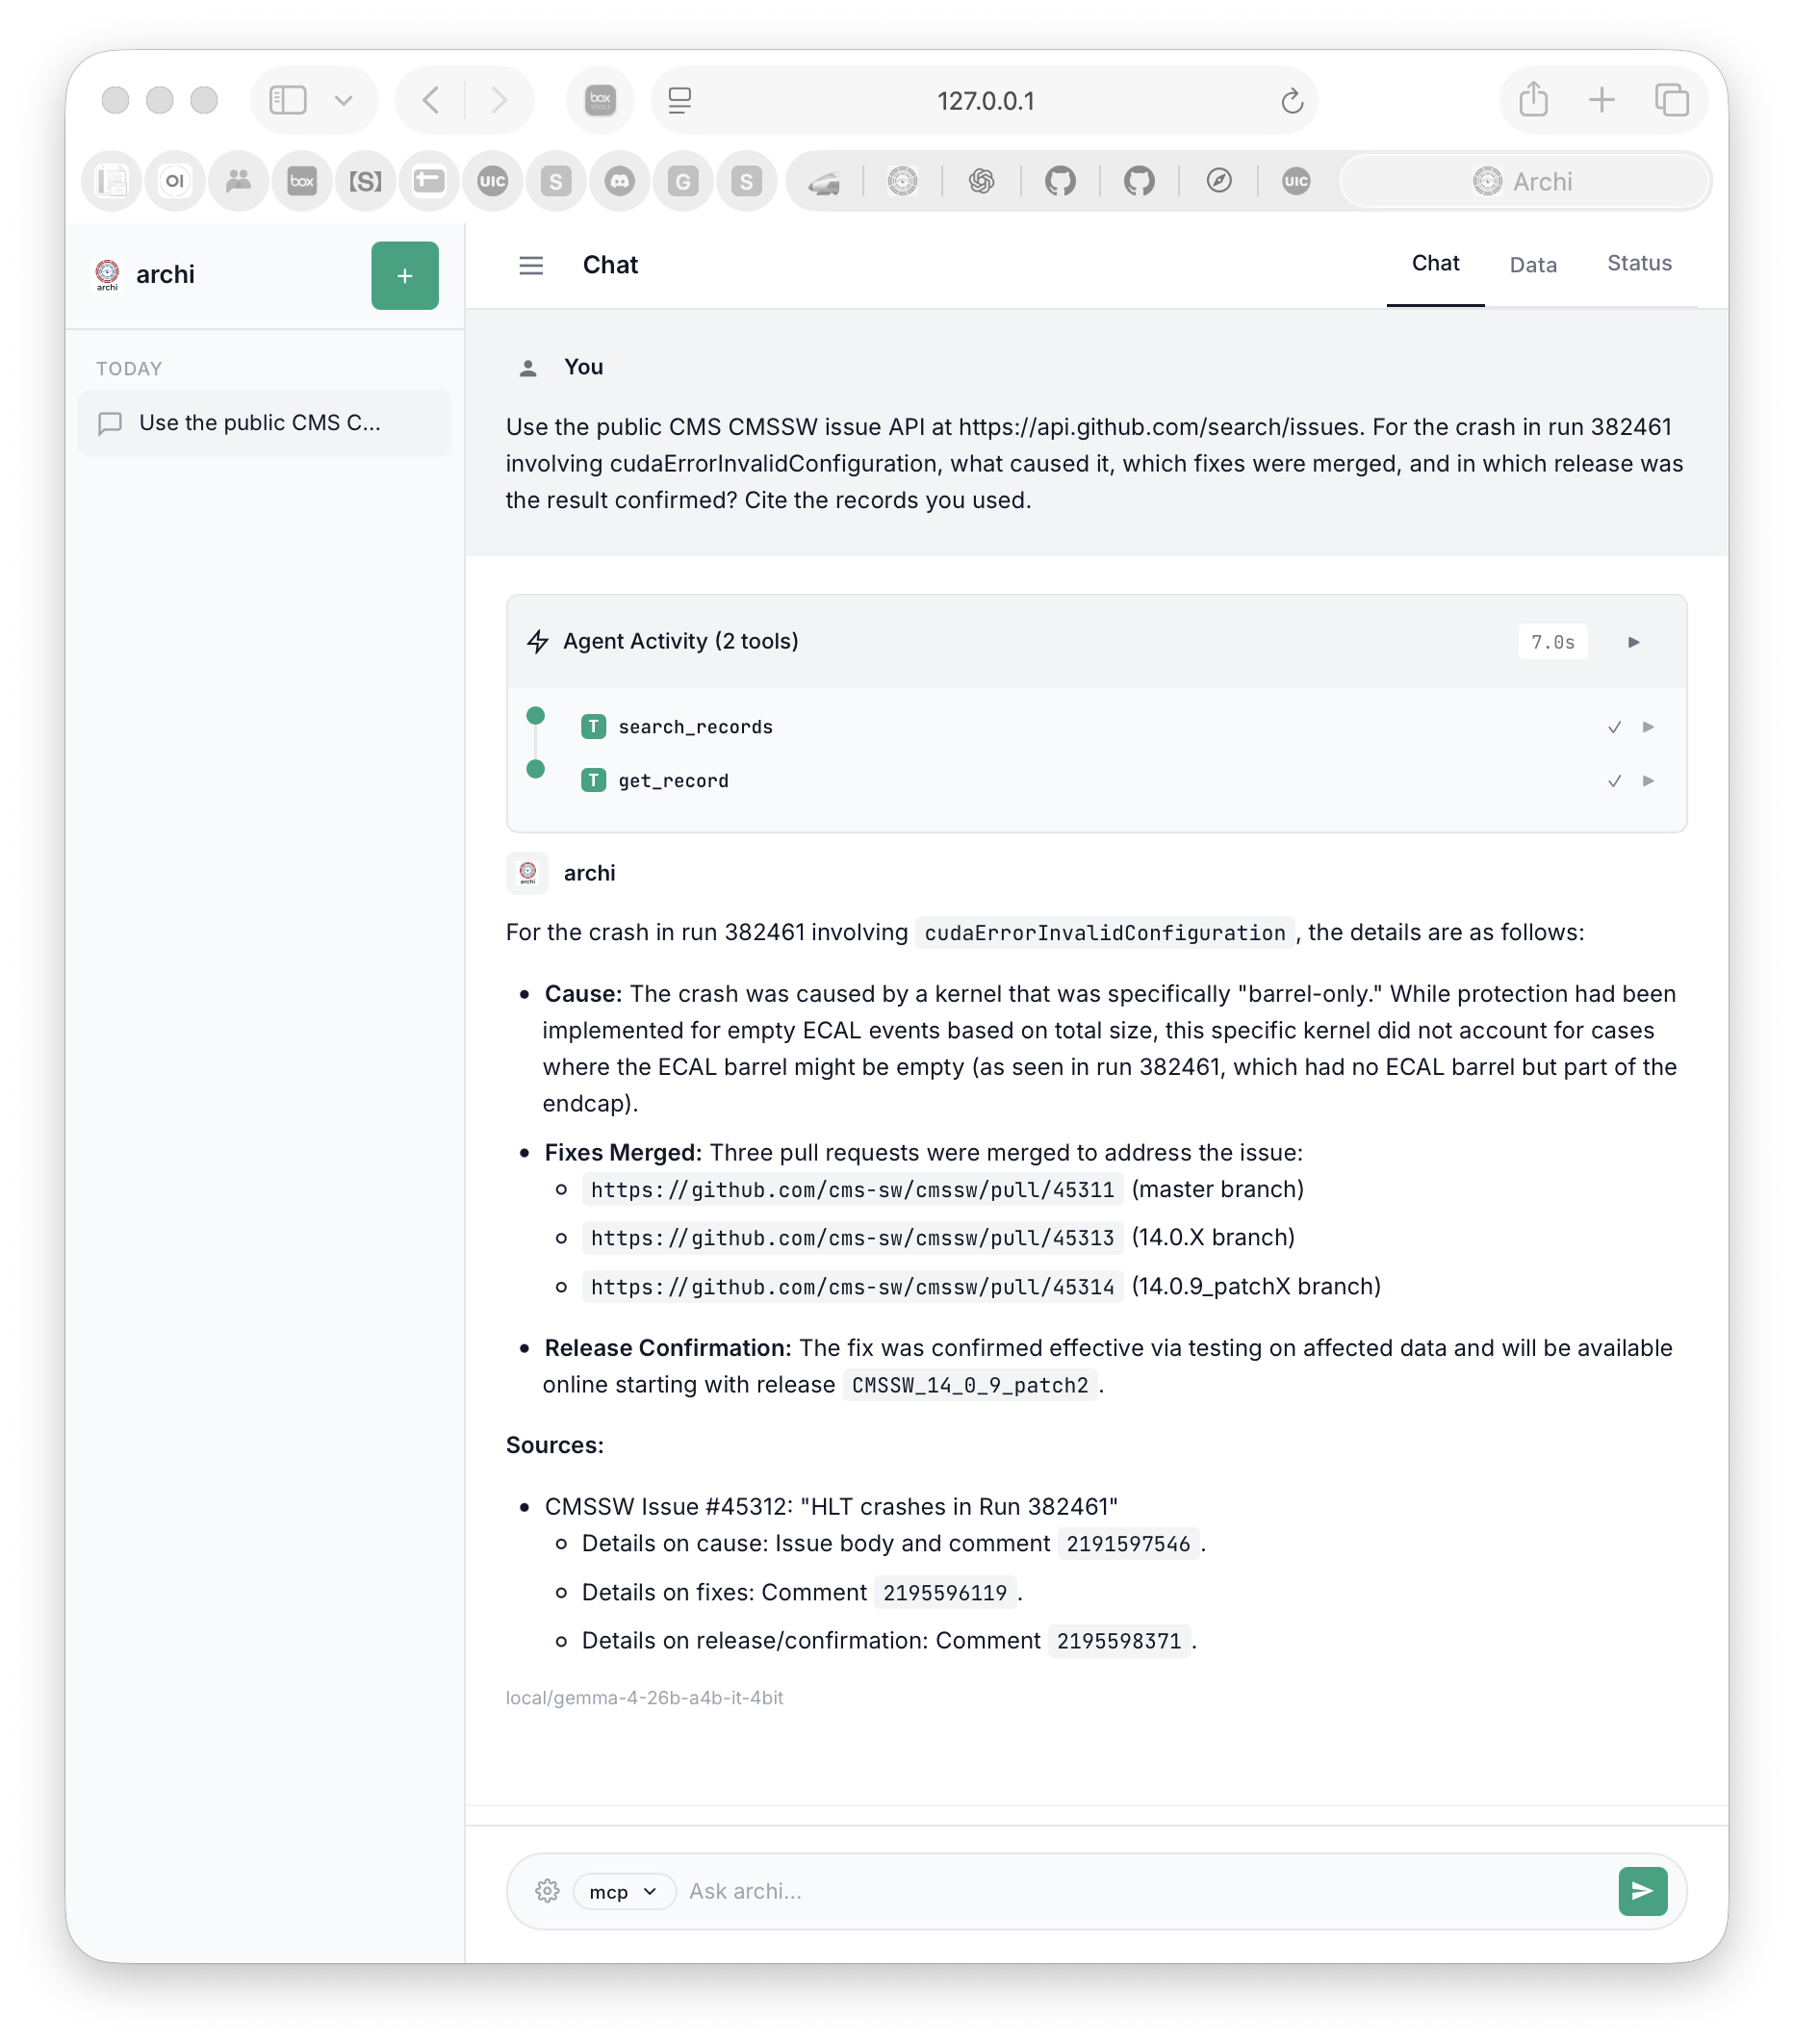
